# Occlusion sensitivity of the sub_model

Sources:  
https://github.com/BUPTLdy/occlusion_experiments/blob/master/Occlusion_experiments.ipynb  
https://github.com/oswaldoludwig/Sensitivity-to-occlusion-Keras-/blob/master/occlusion_sensitivity.py  
https://github.com/matheushent/covid-19-detector/blob/master/vis.py  
https://pypi.org/project/tf-explain/0.0.1a0/  
https://www.mdpi.com/1424-8220/20/11/3307

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf


2025-11-09 20:27:53.492465: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-09 20:27:53.492628: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-09 20:27:53.494221: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-09 20:27:53.512548: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-09 20:27:53.931413: W tensorflow/compiler/tf2tensorrt/uti

In [2]:
def set_reproducible():
    np.random.seed(12345)
    random.seed(12345)
    tf.random.set_seed(12345)
    keras.utils.set_random_seed(12345)
    
set_reproducible()

In [3]:
dps1200 = pd.read_csv("../../data/dps1200.csv")
dps1200.rename(columns=lambda x: x.lower(), inplace=True)
dpa = pd.read_csv("../../data/dpa.csv")
dpa.rename(columns=lambda x: x.lower(), inplace=True)
daa = pd.read_csv("../../data/daa.csv")
daa.rename(columns=lambda x: x.lower(), inplace=True)

frames = [dpa, daa, dps1200]

data = pd.concat(frames)

In [4]:
data.rename(columns=lambda x: x.replace('x', '').strip(), inplace=True)
data = data.drop('tree', axis=1)
data = data.drop('type', axis=1)

data.head()

,year,origin,jahr,3996,2970,2968,2966,2964,2962,2960,...,818,816,814,812,810,808,806,804,802,800
0,1735,BHN,1735.0,0.006368,0.017754,0.018018,0.018294,0.018581,0.018879,0.019189,...,-0.018907,-0.018778,-0.018669,-0.018587,-0.018535,-0.018516,-0.018530,-0.018577,-0.018652,-0.018751
1,1745,BHN,1745.0,0.006818,0.018299,0.018564,0.018839,0.019124,0.019417,0.019719,...,-0.019323,-0.019172,-0.019042,-0.018940,-0.018870,-0.018835,-0.018837,-0.018873,-0.018940,-0.019035
2,1755,BHN,1755.0,0.007631,0.016718,0.016971,0.017239,0.017520,0.017815,0.018122,...,-0.019671,-0.019498,-0.019348,-0.019226,-0.019140,-0.019092,-0.019085,-0.019116,-0.019183,-0.019282
3,1765,BHN,1765.0,0.007175,0.017103,0.017411,0.017734,0.018068,0.018412,0.018764,...,-0.019654,-0.019498,-0.019362,-0.019255,-0.019180,-0.019142,-0.019141,-0.019175,-0.019242,-0.019338
4,1775,BHN,1775.0,0.008698,0.017788,0.018051,0.018326,0.018608,0.018898,0.019195,...,-0.020540,-0.020391,-0.020261,-0.020158,-0.020087,-0.020049,-0.020047,-0.020079,-0.020142,-0.020234


In [5]:
y = data.iloc[:,4:]
xp = y.columns.values
xp = xp.astype(int)

In [6]:
features = data.iloc[:, 4:].values
labels = data.iloc[:, 0].values

In [7]:
train_data, test_data, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=42)

In [8]:
print(test_data.shape)

(744, 410)


In [9]:
model_path = "all_temp_sub_model.keras"

In [10]:
dps1200sub_model = tf.keras.models.load_model(model_path)

# Show the model architecture
dps1200sub_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

In [11]:
print(type(dps1200sub_model))

<class 'keras.src.models.functional.Functional'>


# Occlusion

In [12]:
import math
import seaborn as sns
import copy

## Feature importance for each sample

744 82
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━

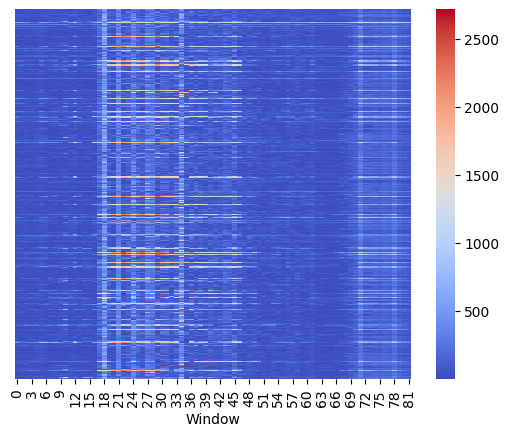

In [13]:
occluding_size = 5
num_columns = test_data.shape[1]
step = occluding_size

output_height = test_data.shape[0]
output_width = math.ceil(num_columns/occluding_size)
print(output_height,output_width)

heatmap = np.zeros((output_height, output_width))
i = 0

for window in range(0, num_columns, step):
   input_data = copy.copy(test_data)
   end_index = min(window + step, num_columns)
   input_data[:, window:end_index] = 0
   output = dps1200sub_model.predict(input_data)
   importance = abs(output.flatten() - test_labels)
   heatmap[:, i] += importance
   i += 1

ax = sns.heatmap(heatmap, cmap='coolwarm', yticklabels=False)
plt.xlabel('Window')
plt.show()
    

## Feature importance for sorted samples

In [14]:
test_labels_2d = test_labels.reshape(-1, 1)
test_all = np.concatenate((test_labels_2d, test_data), axis=1)


sorted_indices = np.argsort(test_all[:, 0])
test_all_sorted = test_all[sorted_indices]

sorted_test_labels = test_all_sorted[:, 0]
sorted_test_data = test_all_sorted[:, 1:]

print("Sortierte Labels:")
print(sorted_test_labels)
print("\nSortierte Daten:")
print(sorted_test_data)

Sortierte Labels:
[-1218. -1178. -1167. -1167. -1157. -1156. -1147. -1146. -1137.  -890.
  -880.  -870.  -865.  -862.  -855.  -840.  -825.  -822.  -808.  -805.
  -792.  -738.  -713.  -707.  -687.  -677.  -666.  -636.  -602.  -552.
  -515.  -512.  -505.  -472.  -452.  -445.  -440.  -435.  -425.  -422.
  -412.  -412.  -405.  -385.  -368.  -365.  -362.  -355.  -348.  -292.
  -268.  -252.  -232.  -228.  -222.  -127.  -116.  -107.   -96.   -87.
   -77.   -16.    -6.   127.   127.   130.   142.   145.   157.   162.
   167.   180.   182.   204.   205.   207.   232.   234.   235.   245.
   247.   267.   317.   327.   357.   362.   405.   465.   485.   495.
   531.   534.   606.   607.   611.   631.   636.   647.   666.   671.
   736.   747.   761.   817.   821.   830.   831.   850.   858.   880.
   919.   954.   960.   979.   984.  1010.  1014.  1031.  1064.  1070.
  1091.  1094.  1120.  1121.  1140.  1170.  1206.  1206.  1220.  1236.
  1239.  1240.  1244.  1246.  1276.  1279.  1296.  1309.  1

744 82
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
24/24 ━━━━━━━━━━━━

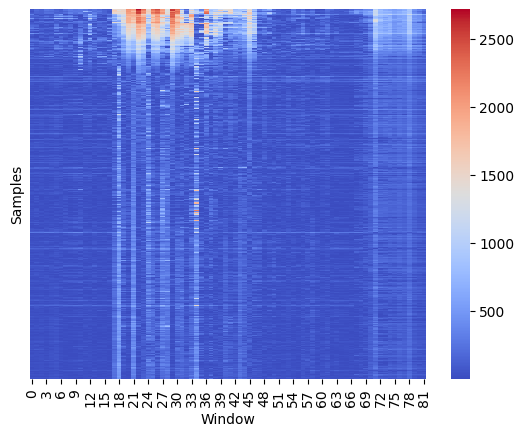

In [15]:
occluding_size = 5
num_columns = sorted_test_data.shape[1]
step = occluding_size

output_height = sorted_test_data.shape[0]
output_width = math.ceil(num_columns/occluding_size)
print(output_height,output_width)

heatmap = np.zeros((output_height, output_width))
i = 0

for window in range(0, num_columns, step):
   input_data = copy.copy(sorted_test_data)
   end_index = min(window + step, num_columns)
   input_data[:, window:end_index] = 0
   output = dps1200sub_model.predict(input_data)
   importance = abs(output.flatten() - sorted_test_labels)
   heatmap[:, i] += importance
   i += 1

ax = sns.heatmap(heatmap, cmap='coolwarm', yticklabels=False)
plt.xlabel('Window')
plt.ylabel('Samples')
plt.show()

## Feature importance for each century

In [16]:
from typing import List

In [17]:
def convertToCentury(y: List[int]) -> List[int]: 
    return [int(str(year)[:2]) for year in y]
centuries = convertToCentury(sorted_test_labels)

In [18]:
unique_centuries, counts = np.unique(centuries, return_counts=True)
print(unique_centuries, counts)
print(len(counts))

[-9 -8 -7 -6 -5 -4 -3 -2 -1 10 11 12 13 14 15 16 17 18 19 20 23 24 26 31
 32 35 36 40 46 48 49 53 60 61 63 64 66 67 73 74 76 81 82 83 85 88 91 95
 96 97 98] [  1  12   5   6   4  10   6   6  13   7   4  13  32  63  82 105 113 107
 102  14   3   2   1   1   1   1   1   1   1   1   1   2   2   1   2   1
   1   1   1   1   1   1   1   2   2   1   1   1   1   1   1]
51


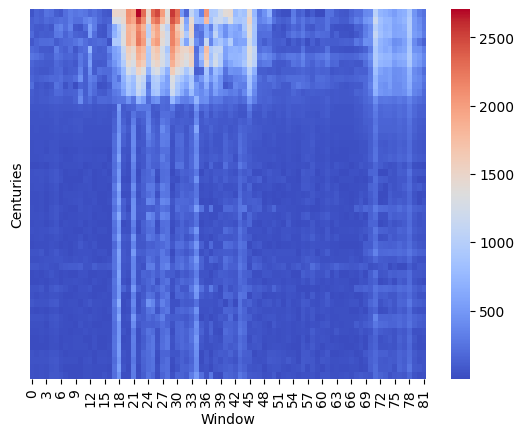

In [19]:
mean_values = []
i = 0
output_height2 = len(counts)
output_width = math.ceil(num_columns/occluding_size)

heatmap2 = np.zeros((output_height2, output_width))

start_row = 0
for count in counts:
    group_data = heatmap[start_row:start_row+count]
    group_mean = np.mean(group_data, axis=0)    
    heatmap2[i,:] += group_mean
    i += 1
    start_row += count

ax = sns.heatmap(heatmap2, cmap='coolwarm', yticklabels=False)
plt.xlabel('Window')
plt.ylabel('Centuries')
plt.show()

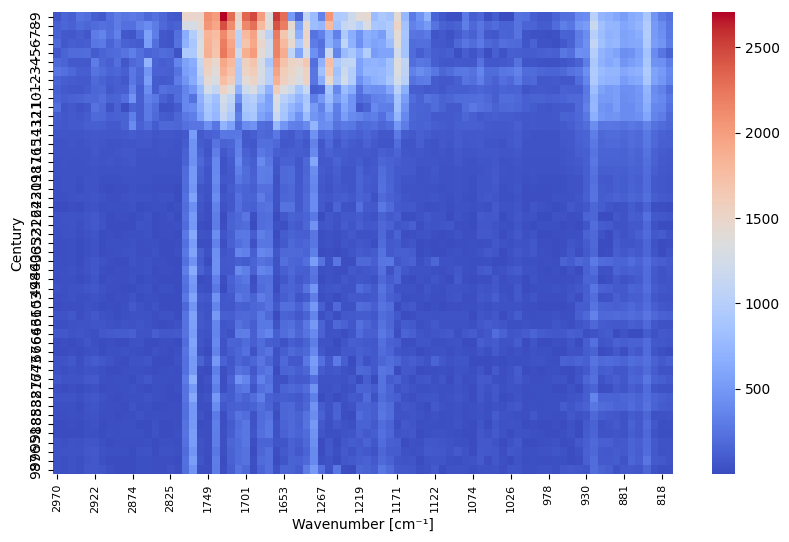

In [20]:
mean_values = []
i = 0
output_height2 = len(counts)
output_width = math.ceil(num_columns/occluding_size)

heatmap2 = np.zeros((output_height2, output_width))

start_row = 0
for count in counts:
    group_data = heatmap[start_row:start_row+count]
    group_mean = np.mean(group_data, axis=0)    
    heatmap2[i,:] += group_mean
    i += 1
    start_row += count

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap2, cmap='coolwarm')
wavelengths = xp[::25]
plt.xticks(ticks=np.arange(0.5, heatmap2.shape[1] + 0.5, 5), labels=wavelengths, fontsize=8)
plt.xlabel('Wavenumber [cm⁻¹]')

centuries = unique_centuries
plt.yticks(ticks=np.arange(0.5, heatmap2.shape[0] + 0.5), labels=centuries)
plt.ylabel('Century')
plt.show()

In [21]:
print(heatmap.shape)

(744, 82)


In [22]:
print(xp.shape)

(410,)


# Heatmap for Comparison

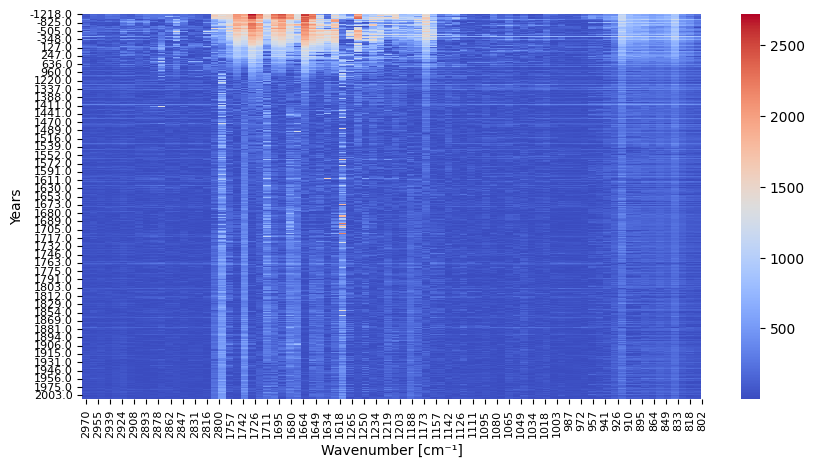

In [23]:
# Plot Heatmap
wavelengths = xp[::8]
years = sorted_test_labels[::16]

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap, cmap='coolwarm')
plt.xlabel('Wavenumber [cm⁻¹]')
plt.ylabel('Years')
plt.xticks(ticks=np.arange(0.5, heatmap.shape[1] + 0.5, 1.6), labels=wavelengths, fontsize=8)
plt.yticks(ticks=np.arange(0.5, heatmap.shape[0] + 0.5, 16), labels=years, fontsize=8)
plt.show()